In [1]:
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt


In [ ]:
# ─── FFT engine (matching AKRA convention) ───
def fft2(x):
    return np.fft.fft2(x)

def ifft2(x):
    return np.fft.ifft2(x)

# ─── Construct mask matrix M ───
def get_mask_matrix(mask):
    """
    Build the mask convolution matrix M column by column.
    
    For each Fourier mode ℓ₁:
      1. Place a delta function at mode ℓ₁
      2. IFFT → real space
      3. Multiply by mask m(θ)
      4. FFT → Fourier space
    The result is column M_{·, ℓ₁}.
    
    This implements the convolution theorem:
      M_{L, ℓ₁} = m̃(L − ℓ₁)
    """
    lx, ly = mask.shape
    N = lx * ly
    M = np.zeros((N, N), dtype=np.complex128)
    
    for i in range(N):
        # Delta function at mode i
        delta = np.zeros(N, dtype=np.float64)
        delta[i] = 1.0
        
        # IFFT to real space
        delta_real = ifft2(delta.reshape(lx, ly))
        
        # Multiply by mask in real space
        masked = mask * delta_real
        
        # FFT back to Fourier space → column i of M
        M[:, i] = fft2(masked).flatten()
    
    return M

def get_M_fastest(mask):
    lx, ly = mask.shape
    N = lx * ly
    
    b_k = fft2(mask) / N
    
    # Precompute all shifts using stride tricks or index manipulation
    # Create index arrays for rolled access
    ix_col = np.arange(N) // ly  # shape (N,)
    iy_col = np.arange(N) % ly   # shape (N,)
    
    ix_row = np.arange(lx)[:, np.newaxis, np.newaxis]  # shape (lx, 1, 1)
    iy_row = np.arange(ly)[np.newaxis, :, np.newaxis]  # shape (1, ly, 1)
    
    # Compute rolled indices
    ix_shifted = (ix_row - ix_col) % lx  # shape (lx, 1, N)
    iy_shifted = (iy_row - iy_col) % ly  # shape (1, ly, N)
    
    # Gather values
    M = b_k[ix_shifted, iy_shifted].reshape(N, N)
    
    return M

In [3]:
np.random.seed(42)
N = 32  # 32×32 grid (small enough for explicit M)

# 1. Generate a random map (Gaussian random field)
test_map = np.random.randn(N, N)

# 2. Generate a random mask (circular hole + rectangular strip)
mask = np.ones((N, N), dtype=np.float64)
# Circular hole at center
yy, xx = np.mgrid[:N, :N]
r = np.sqrt((xx - N//2)**2 + (yy - N//2)**2)
mask[r < N//6] = 0.0
# Rectangular strip
mask[3:6, :] = 0.0
# Random scattered pixels
mask[np.random.rand(N, N) < 0.05] = 0.0

print(f"Grid size: {N}×{N} = {N**2} modes")
print(f"Mask fraction: {1 - mask.mean():.1%} masked")
print(f"Matrix M size: {N**2}×{N**2} = {N**4:,} elements")
print(f"Memory: {N**4 * 16 / 1e6:.1f} MB (complex128)")
print()

Grid size: 32×32 = 1024 modes
Mask fraction: 19.6% masked
Matrix M size: 1024×1024 = 1,048,576 elements
Memory: 16.8 MB (complex128)



In [4]:
# ─── Method 1: Direct real-space multiplication ───
# masked_map = mask × test_map
# then FFT to Fourier space-
masked_map_real = mask * test_map
result_direct = fft2(masked_map_real).flatten()

# ─── Method 2: Matrix multiplication in Fourier space ───
# FFT(mask × map) = M · FFT(map)
print("Constructing mask matrix M column by column...")
M = get_M_fastest(mask)

kappa_fft = fft2(test_map).flatten()
result_matrix = M @ kappa_fft

Constructing mask matrix M column by column...


In [5]:
# ─── Compare ───
diff = np.abs(result_direct - result_matrix)
max_diff = np.max(diff)
rel_diff = np.max(diff) / np.max(np.abs(result_direct))

print(f"\n{'='*60}")
print(f"  VALIDATION: FFT(mask · map)  vs  M · FFT(map)")
print(f"{'='*60}")
print(f"  Max absolute difference:  {max_diff:.2e}")
print(f"  Max relative difference:  {rel_diff:.2e}")
print(f"  Machine epsilon:          {np.finfo(np.float64).eps:.2e}")
print(f"  Match: {'YES ✓' if rel_diff < 1e-10 else 'NO ✗'}")
print(f"{'='*60}")


  VALIDATION: FFT(mask · map)  vs  M · FFT(map)
  Max absolute difference:  1.53e-13
  Max relative difference:  2.26e-15
  Machine epsilon:          2.22e-16
  Match: YES ✓


In [6]:
# ─── Also verify: without mask, M → I ───
print("\nSanity check: M → I when mask = 1 everywhere?")
mask_full = np.ones((N, N))
M_full = get_mask_matrix(mask_full)
identity_diff = np.max(np.abs(M_full - np.eye(N**2)))
print(f"  max|M_full − I| = {identity_diff:.2e}")
print(f"  Match: {'YES ✓' if identity_diff < 1e-10 else 'NO ✗'}")



Sanity check: M → I when mask = 1 everywhere?
  max|M_full − I| = 1.68e-16
  Match: YES ✓


In [7]:
%matplotlib inline

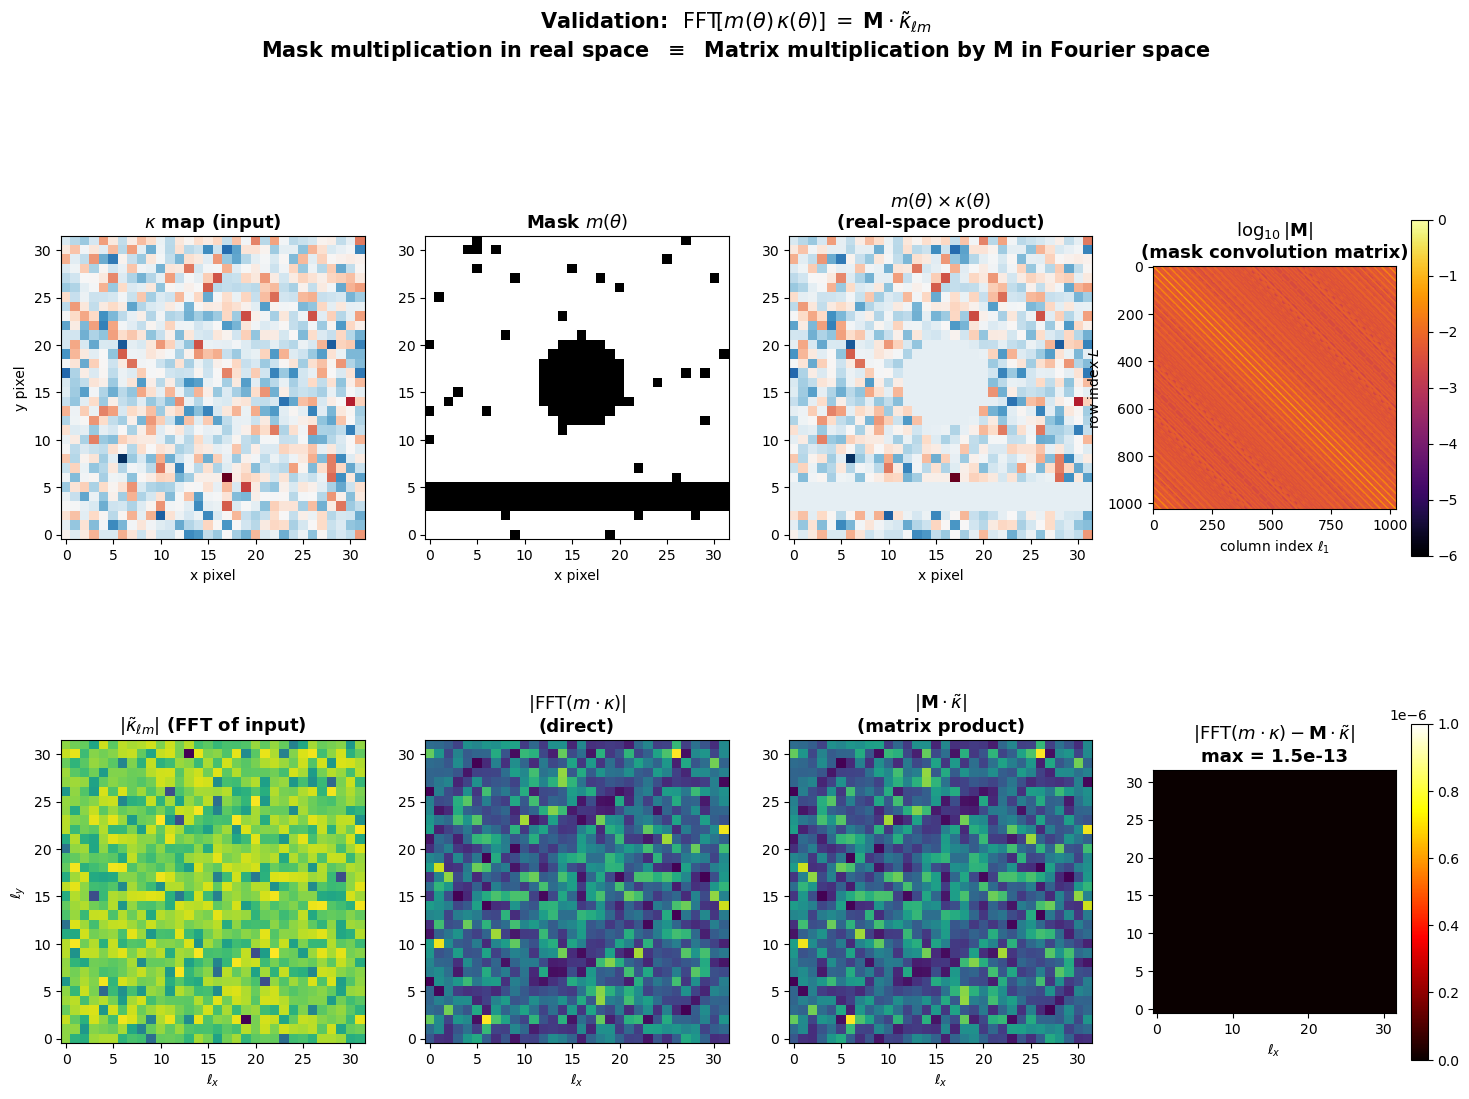

In [8]:

fig, axes = plt.subplots(2, 4, figsize=(18, 12))

# Row 1: Real-space picture
axes[0, 0].imshow(test_map, cmap='RdBu_r', origin='lower')
axes[0, 0].set_title(r'$\kappa$ map (input)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('x pixel')
axes[0, 0].set_ylabel('y pixel')

axes[0, 1].imshow(mask, cmap='gray', origin='lower', vmin=0, vmax=1)
axes[0, 1].set_title(r'Mask $m(\theta)$', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('x pixel')

axes[0, 2].imshow(masked_map_real, cmap='RdBu_r', origin='lower')
axes[0, 2].set_title(r'$m(\theta) \times \kappa(\theta)$' + '\n(real-space product)', fontsize=13, fontweight='bold')
axes[0, 2].set_xlabel('x pixel')

# Show mask matrix structure
im = axes[0, 3].imshow(np.log10(np.abs(M) + 1e-15), cmap='inferno', 
                        aspect='equal', vmin=-6, vmax=0)
axes[0, 3].set_title(r'$\log_{10}|\mathbf{M}|$' + '\n(mask convolution matrix)', fontsize=13, fontweight='bold')
axes[0, 3].set_xlabel(r'column index $\ell_1$')
axes[0, 3].set_ylabel(r'row index $L$')
plt.colorbar(im, ax=axes[0, 3], shrink=0.8)

# Row 2: Fourier-space comparison
axes[1, 0].imshow(np.log10(np.abs(kappa_fft).reshape(N, N) + 1e-15), 
                   cmap='viridis', origin='lower')
axes[1, 0].set_title(r'$|\tilde{\kappa}_{\ell m}|$ (FFT of input)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel(r'$\ell_x$')
axes[1, 0].set_ylabel(r'$\ell_y$')

axes[1, 1].imshow(np.abs(result_direct).reshape(N, N), 
                   cmap='viridis', origin='lower')
axes[1, 1].set_title(r'$|\mathrm{FFT}(m \cdot \kappa)|$' + '\n(direct)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel(r'$\ell_x$')

axes[1, 2].imshow(np.abs(result_matrix).reshape(N, N), 
                   cmap='viridis', origin='lower')
axes[1, 2].set_title(r'$|\mathbf{M} \cdot \tilde{\kappa}|$' + '\n(matrix product)', fontsize=13, fontweight='bold')
axes[1, 2].set_xlabel(r'$\ell_x$')

# Difference
im_diff = axes[1, 3].imshow(diff.reshape(N, N), cmap='hot', origin='lower', vmin=0, vmax=1e-6)
axes[1, 3].set_title(r'$|\mathrm{FFT}(m\cdot\kappa) - \mathbf{M}\cdot\tilde{\kappa}|$' + 
                      f'\nmax = {max_diff:.1e}', fontsize=13, fontweight='bold')
axes[1, 3].set_xlabel(r'$\ell_x$')
plt.colorbar(im_diff, ax=axes[1, 3], shrink=0.8)

# Title
fig.suptitle(
    r'Validation:  $\mathrm{FFT}\!\left[m(\theta)\,\kappa(\theta)\right] '
    r'\;=\; \mathbf{M} \cdot \tilde{\kappa}_{\ell m}$'
    '\n'
    r'Mask multiplication in real space  $\equiv$  Matrix multiplication by $\mathbf{M}$ in Fourier space',
    fontsize=15, fontweight='bold', y=1.02
)

# plt.tight_layout()
plt.show()


  EIGENVALUE ANALYSIS OF A^T A
  Largest eigenvalue:   1.000000
  Smallest eigenvalue:  -1.78e-15
  Condition number:     1.00e+15
  No mask → largest eigenvalue = 1.0 (A^T A = I)
  With mask → some eigenvalues → 0 (mode coupling)
  λ = 10⁻³ regularizes these near-zero modes


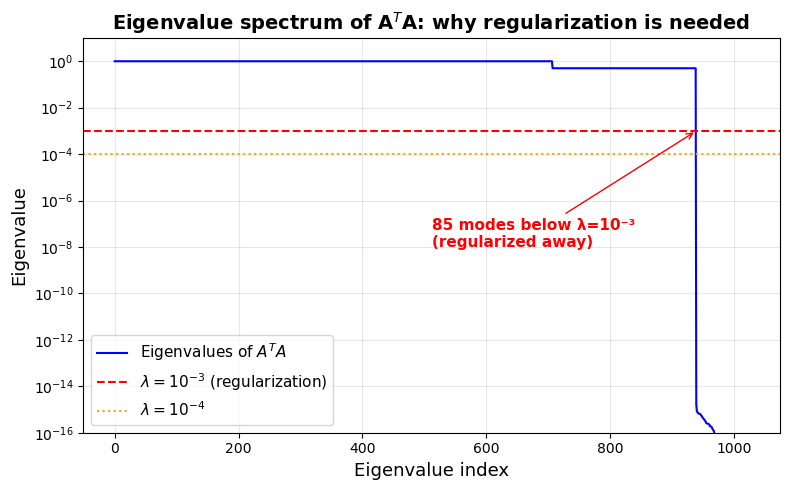

In [9]:
# ─── Print eigenvalue info (relevant for regularization discussion) ───
### Details comparison can see Appendix in AKRA 1.0

print("\n" + "="*60)
print("  EIGENVALUE ANALYSIS OF A^T A")
print("="*60)

# Build the full A matrix: A = [cos(2φ)·M; sin(2φ)·M]
ell_x = np.fft.fftfreq(N, d=1.0/N)
ell_y = np.fft.fftfreq(N, d=1.0/N)
EX, EY = np.meshgrid(ell_x, ell_y)
phi_ell = np.arctan2(EY, EX).flatten()

cos2phi = np.diag(np.cos(2 * phi_ell))
sin2phi = np.diag(np.sin(2 * phi_ell))

A = np.vstack([cos2phi @ M, sin2phi @ M])
ATA = A.T.conj() @ A

eigvals = np.linalg.eigvalsh(ATA.real)
eigvals_sorted = np.sort(eigvals)[::-1]

print(f"  Largest eigenvalue:   {eigvals_sorted[0]:.6f}")
print(f"  Smallest eigenvalue:  {eigvals_sorted[-1]:.2e}")
print(f"  Condition number:     {eigvals_sorted[0]/max(eigvals_sorted[-1], 1e-15):.2e}")
print(f"  No mask → largest eigenvalue = 1.0 (A^T A = I)")
print(f"  With mask → some eigenvalues → 0 (mode coupling)")
print(f"  λ = 10⁻³ regularizes these near-zero modes")

# Eigenvalue plot
fig2, ax2 = plt.subplots(1, 1, figsize=(8, 5))
ax2.semilogy(np.arange(len(eigvals_sorted)), eigvals_sorted, 'b-', linewidth=1.5, label='Eigenvalues of $A^T A$')
ax2.axhline(y=1e-3, color='r', linestyle='--', linewidth=1.5, label=r'$\lambda = 10^{-3}$ (regularization)')
ax2.axhline(y=1e-4, color='orange', linestyle=':', linewidth=1.5, label=r'$\lambda = 10^{-4}$')
ax2.set_xlabel('Eigenvalue index', fontsize=13)
ax2.set_ylabel('Eigenvalue', fontsize=13)
ax2.set_title(r'Eigenvalue spectrum of $\mathbf{A}^T\mathbf{A}$: why regularization is needed', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.set_ylim(1e-16, 10)
ax2.grid(True, alpha=0.3)

# Annotate
n_below = np.sum(eigvals_sorted < 1e-3)
ax2.annotate(f'{n_below} modes below λ=10⁻³\n(regularized away)', 
             xy=(len(eigvals_sorted)-n_below, 1e-3), 
             xytext=(len(eigvals_sorted)*0.5, 1e-8),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=11, color='red', fontweight='bold')

plt.tight_layout()
plt.show()